# **EDA and Churn Prediction**

# How to Segment and Retain a Customer from Churn?

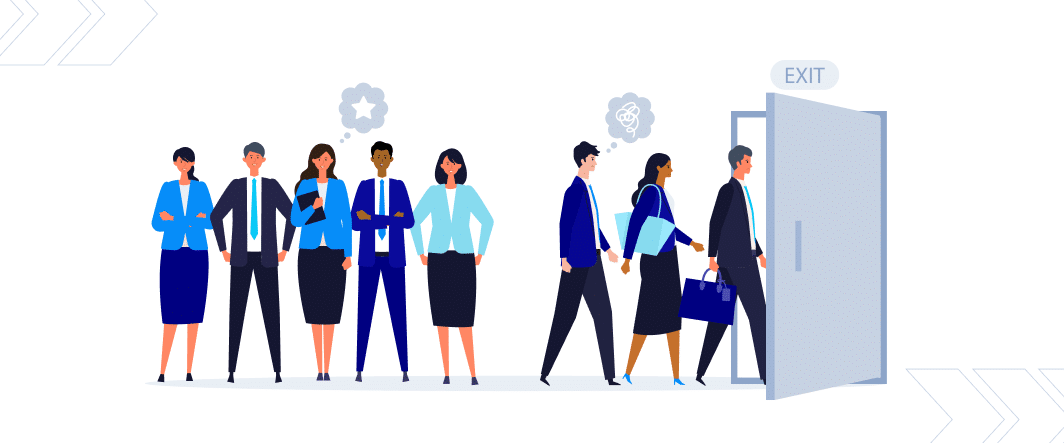

**OVERVIEW**

**Business Understanding:**

This project focuses on analyzing customer transaction data from an e-commerce platform to understand purchasing behavior, segment customers, and predict churn risk. The dataset contains large-scale transaction records including product purchases, quantities, pricing, and customer identifiers. The objective is to derive actionable business insights using exploratory data analysis (EDA), customer segmentation using clustering techniques, and machine learning models for churn prediction. The results help identify high-value customers, at-risk customers, and behavioral patterns that support retention strategies.

**Introduction**

E-commerce businesses generate large volumes of transactional data.Understanding customer behavior is critical for improving retention and revenue. This project aims to analyze customer transactions to,

*   Understand purchasing patterns
*   Segment customers based on behavior
*   Predict potential churn using machine learning models


**Dataset Understanding**

This is a transnational data set which contains all the transactions that occurred between 01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retail. The company mainly sells unique and all-occasion gifts.
Below are the different features we will be exploring into.

*   Variables: Description
*   InvoiceNo: Invoice number. Nominal, a six digit integral number uniquely assigned to each transaction. If this code starts with letter 'c', it indicates a cancellation
*   StockCode: Product (item) code. Nominal, a five digit integral number uniquely assigned to each distinct product
*   Description: Product (item) name. Nominal
*   Quantity: The quantities of each product (item) per transaction. Numeric
InvoiceDate: Invoice Date and time. Numeric, the day and time when each transaction was generated
*   UnitPrice: Unit price. Numeric, product price per unit in sterling
CustomerID Customer number. Nominal, a six digit integral number uniquely assigned to each customer
*   Country Country name. Nominal, the name of the country where each customer resides

# **1. DATA UNDERSTANDING**

In [2]:
#Import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [4]:
#Load the Data:
data = pd.read_excel("/content/Online Retail.xlsx")


In [5]:
#Check basic information about Dataframe
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [6]:
#Listing First five rows of data
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [7]:
#Listing Last five rows of data
data.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [8]:
# Statistical summary of numeric column
data.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [9]:
# The "Percentile Cutoff" Method to find outliers with custom percentiles

data.describe(percentiles=[.05, .25, .5, .75, .95])

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
5%,1.000000,2010-12-13 09:35:00,0.420000,12626.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
95%,29.000000,2011-11-30 14:41:00,9.950000,17905.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


**OBSERVATION**

1. Compare the count of Quantity (541,909) to CustomerID (406,829) which indicates missing Data.
2. min is -80,995 and your max is 80,995
Since the 5th percentile is 1.0 and the 95th is only 29.0, these eighty-thousand-plus values are massive outliers. The fact they are identical suggests a "cancelled order" logic where a large purchase was later fully reversed.
3. 95th percentile is only 9.95. A jump from 10 dollors to nearly $39,000 indicates outlier in the Data. This huge spike in price might be Administrative Fee, Cancellation Charges rather than a item price.

In [10]:
#Check the number of null values in each feature
data.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [11]:
#Shape of the DataFrame - (number of rows and columns)
data.shape

(541909, 8)

In [12]:
#Check unique values for each feature
unique = data.nunique(axis = 0)
unique

,0
InvoiceNo,25900
StockCode,4070
Description,4223
Quantity,722
InvoiceDate,23260
UnitPrice,1630
CustomerID,4372
Country,38


**Histogram of the DataFrame before Data Cleaning**

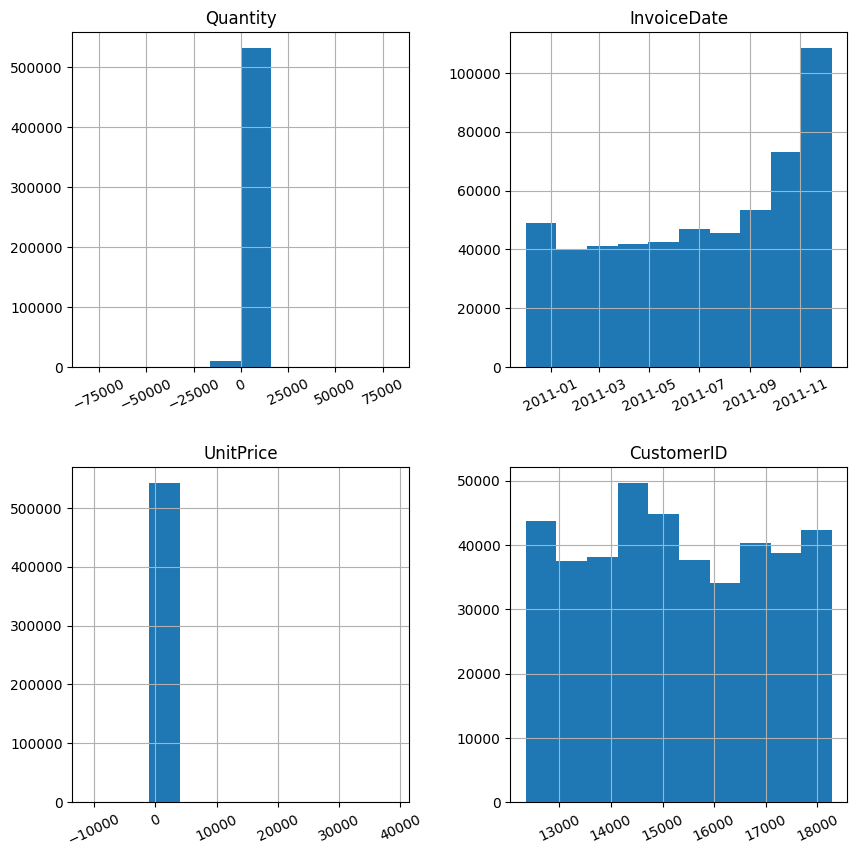

In [13]:
data.hist(xrot=25, figsize=(10, 10))
plt.show()

# **2. DATA CLEANING**

Null values in CustomerID will not be helpful in our analysis, hence deleting it.

In [14]:
#Dropping null values
data_clean = data.copy()
data_clean = data_clean.dropna(subset=['CustomerID'])
data_clean.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


After dropping null values in customer id, the shape of dataframe from
(541,909, 8) reduced to (406829, 8).
we have about 135,000 rows missing CustomerID rows and these rows are "outliers" in the sense that they lack the primary key needed for analysis.

In [15]:
#DataFrame size now
data_clean.shape

(406829, 8)

In [16]:
#Dropping Duplicates
data_clean = data_clean.drop_duplicates(keep='first')
print(f"Number of duplicates after cleaning: {data_clean.duplicated().sum()}")

print("\nDataFrame size:")
print(data_clean.shape)

Number of duplicates after cleaning: 0

DataFrame size:
(401604, 8)


In [17]:
# Remove obvious errors (Negative prices and quantities)
# Prices shouldn't be negative, and negative quantities are usually returns/cancellations

data_clean = data_clean[(data_clean['Quantity'] > 0) & (data_clean['UnitPrice'])]

print(data_clean.info())
print(data_clean.shape)

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.0+ MB
None
(392692, 8)


In [18]:
#Before and after cleaning Dataframe length
print(f"Original rows: {len(data)}")
print(f"Cleaned rows: {len(data_clean)}")

Original rows: 541909
Cleaned rows: 392692


# **3. FEATURE ENGINEERING**

Calculate TotalAmount of the items in each row, segregate the Year, Daysofthe week, Month separately to find the relationship with sales and customer behavior.

In [19]:
#Calculate TotalAmount, segregate Year, Days of the week, Month separately to find the relationship with sales
data_clean['TotalAmount'] = data_clean['Quantity'] * data_clean['UnitPrice']

data_clean['Year'] = data_clean['InvoiceDate'].dt.year
data_clean['Month'] = data_clean['InvoiceDate'].dt.month
data_clean['YearMonth'] = data_clean['InvoiceDate'].dt.to_period('M').astype(str)
data_clean['DayOfWeek'] = data_clean['InvoiceDate'].dt.day_name()
data_clean['Hour'] = data_clean['InvoiceDate'].dt.hour

In [20]:
data_clean

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,Year,Month,YearMonth,DayOfWeek,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,2010-12,Wednesday,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,2010-12,Wednesday,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,2010-12,Wednesday,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,2010-12,Wednesday,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,2010-12,Wednesday,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,2011,12,2011-12,Friday,12
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,2011,12,2011-12,Friday,12
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011,12,2011-12,Friday,12
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011,12,2011-12,Friday,12


In [21]:
# Revenue per Customer (Customer Lifetime Value)
customer_revenue = data_clean.groupby('CustomerID')['TotalAmount'].sum().sort_values(ascending=False).reset_index()

# Revenue per Product (Best Sellers by Cash)
product_revenue = data_clean.groupby('Description')['TotalAmount'].sum().sort_values(ascending=False).reset_index()

print("Top 50 Customers by Revenue:")
print(customer_revenue.head(50))

Top 50 Customers by Revenue:
    CustomerID  TotalAmount
0      14646.0    280206.02
1      18102.0    259657.30
2      17450.0    194390.79
3      16446.0    168472.50
4      14911.0    143711.17
5      12415.0    124914.53
6      14156.0    117210.08
7      17511.0     91062.38
8      16029.0     80850.84
9      12346.0     77183.60
10     16684.0     66653.56
11     14096.0     65164.79
12     13694.0     65039.62
13     15311.0     60632.75
14     13089.0     58762.08
15     17949.0     58510.48
16     15769.0     56252.72
17     15061.0     54534.14
18     14298.0     51527.30
19     14088.0     50491.81
20     15749.0     44534.30
21     12931.0     42055.96
22     17841.0     40519.84
23     15098.0     39916.50
24     13798.0     37153.85
25     16013.0     37130.60
26     16422.0     34684.40
27     15838.0     33643.08
28     12748.0     33053.19
29     17404.0     31906.82
30     17389.0     31833.68
31     13098.0     28882.44
32     14680.0     28754.11
33     13081.0     

In [22]:
# Aggregate revenue by month
monthly_revenue = (
    data_clean
    .groupby('YearMonth')['TotalAmount']
    .sum()
    .reset_index()
    .sort_values('YearMonth')
)

monthly_revenue.head()

,YearMonth,TotalAmount
0,2010-12,570422.730
1,2011-01,568101.310
2,2011-02,446084.920
3,2011-03,594081.760
4,2011-04,468374.331


# **4. Data visualization**

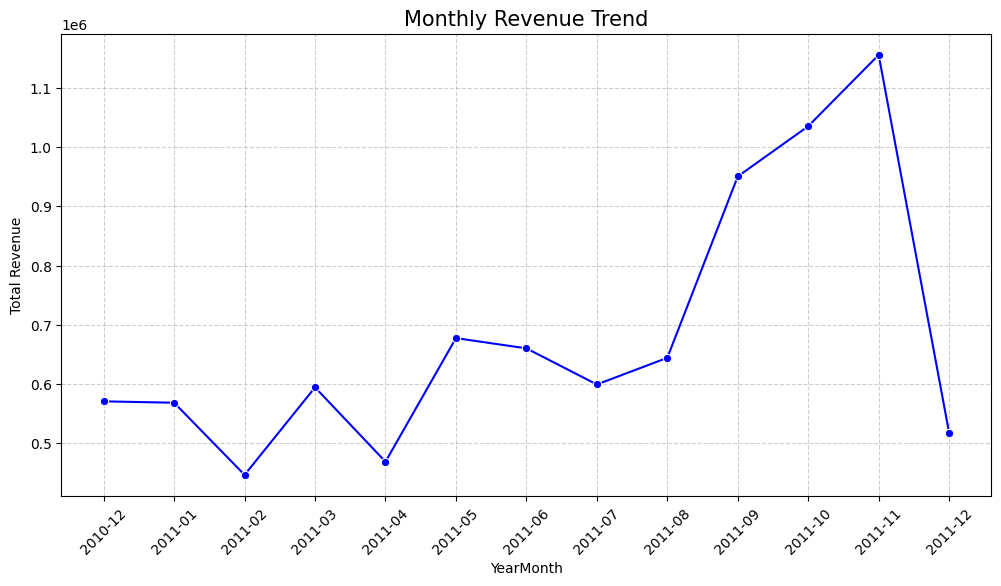

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by the YearMonth you just created
monthly_sales = data_clean.groupby('YearMonth')['TotalAmount'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_sales, x='YearMonth', y='TotalAmount', marker='o', color='b')
plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend', fontsize=15)
plt.ylabel('Total Revenue')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


**Insights:**

Revenue shows clear seasonality with noticeable peaks, particularly in September-November (Q4), indicating strong holiday season demand
The business experiences cyclical patterns with consistent year-over-year growth trends
Summer months (June-August) show relatively lower revenue, suggesting seasonal demand fluctuations
This seasonality helps identify high-demand periods for inventory planning and marketing campaigns

In [24]:
#Segregate the sales rate by days
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
data_clean['DayOfWeek'] = pd.Categorical(data_clean['DayOfWeek'], categories=day_order, ordered=True)

In [25]:
#Higher sales day visual presentation
daily_sales = data_clean.groupby('DayOfWeek', observed=True)['TotalAmount'].sum().reset_index()

fig = px.bar(daily_sales,
             x='DayOfWeek',
             y='TotalAmount',
             title='Total Sales Volume by Day of the Week',
             labels={'TotalAmount': 'Total Sales ($)', 'DayOfWeek': 'Day'},
             color='TotalAmount',
             color_continuous_scale='Blues')


fig.update_layout(xaxis_title="Day of the Week",
                  yaxis_title="Total Sales",
                  template="plotly_white")

fig.show()

In [26]:
#Analysing which country made more revenue
country_revenue_top10 = (
  data_clean.groupby('Country')['TotalAmount']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print(country_revenue_top10.head(10))

          Country  TotalAmount
0  United Kingdom  7285024.644
1     Netherlands   285446.340
2            EIRE   265262.460
3         Germany   228678.400
4          France   208934.310
5       Australia   138453.810
6           Spain    61558.560
7     Switzerland    56443.950
8         Belgium    41196.340
9          Sweden    38367.830


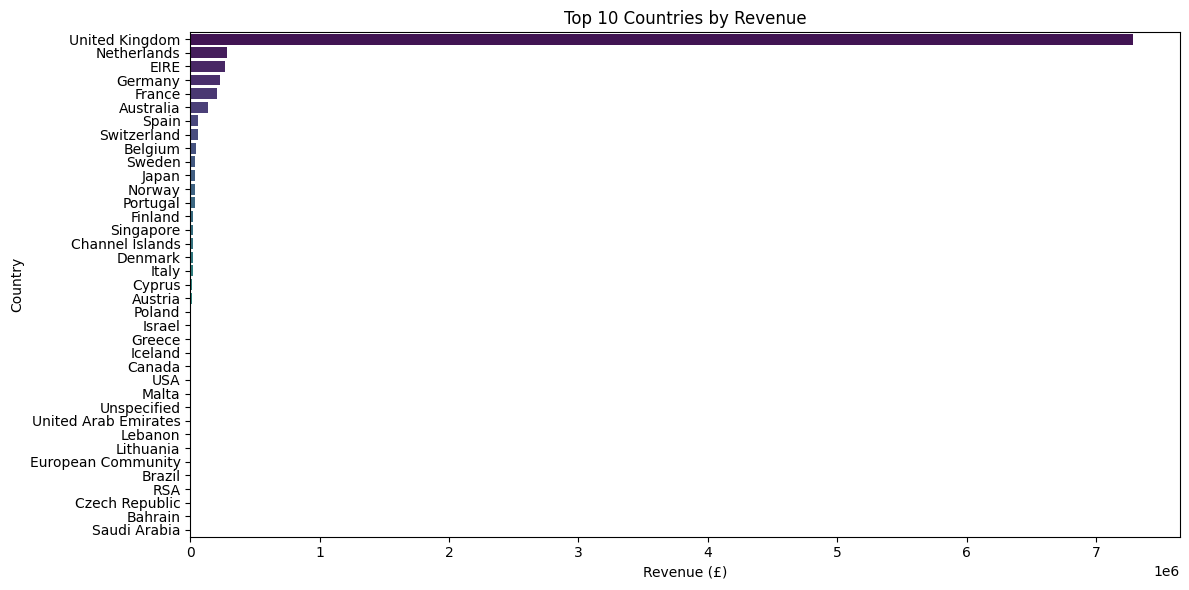

In [27]:
#Visual presentation of top 10 countries by revenue
plt.figure(figsize=(12,6))

sns.barplot(
    data=country_revenue_top10,
    x='TotalAmount',
    y='Country',
    order=country_revenue_top10.sort_values(by='TotalAmount', ascending=False)['Country'],
    palette='viridis'
)

# Titles and labels
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Revenue (£)')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

**Insights:**

United Kingdom dominates with £14.7M in revenue, representing 83.0% of total £17.7M revenue

Next largest markets are Australia (£170K, 1.0%), Belgium (£66K, 0.4%), and Austria (£24K, 0.1%)

Extreme geographic concentration risk: Top country generates 83× more than the second-largest market

Only 1 country exceeds 1% of revenue, indicating highly localized business model with limited international diversification

International markets combined contribute only 17%, representing significant untapped expansion opportunity

In [28]:
# Best selling by TOTAL MONEY generated
product_revenue = data_clean.groupby('Description')['TotalAmount'].sum().sort_values(ascending=False).reset_index()
print("Best selling by TOTAL MONEY:\n", product_revenue)


# Best selling by TOTAL QUANTITY (volume) sold
product_volume = data_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).reset_index()
print("Best selling by TOTAL QUANTITY:\n",product_volume)

Best selling by TOTAL MONEY:
                              Description  TotalAmount
0            PAPER CRAFT , LITTLE BIRDIE   168469.600
1               REGENCY CAKESTAND 3 TIER   142264.750
2     WHITE HANGING HEART T-LIGHT HOLDER   100392.100
3                JUMBO BAG RED RETROSPOT    85040.540
4         MEDIUM CERAMIC TOP STORAGE JAR    81416.730
...                                  ...          ...
3872          PURPLE FRANGIPANI HAIRCLIP        0.850
3873            VINTAGE BLUE TINSEL REEL        0.840
3874     SET 12 COLOURING PENCILS DOILEY        0.650
3875           HEN HOUSE W CHICK IN NEST        0.420
3876          PADS TO MATCH ALL CUSHIONS        0.003

[3877 rows x 2 columns]
Best selling by TOTAL QUANTITY:
                               Description  Quantity
0             PAPER CRAFT , LITTLE BIRDIE     80995
1          MEDIUM CERAMIC TOP STORAGE JAR     77916
2       WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
3                 JUMBO BAG RED RETROSPOT     46078
4   

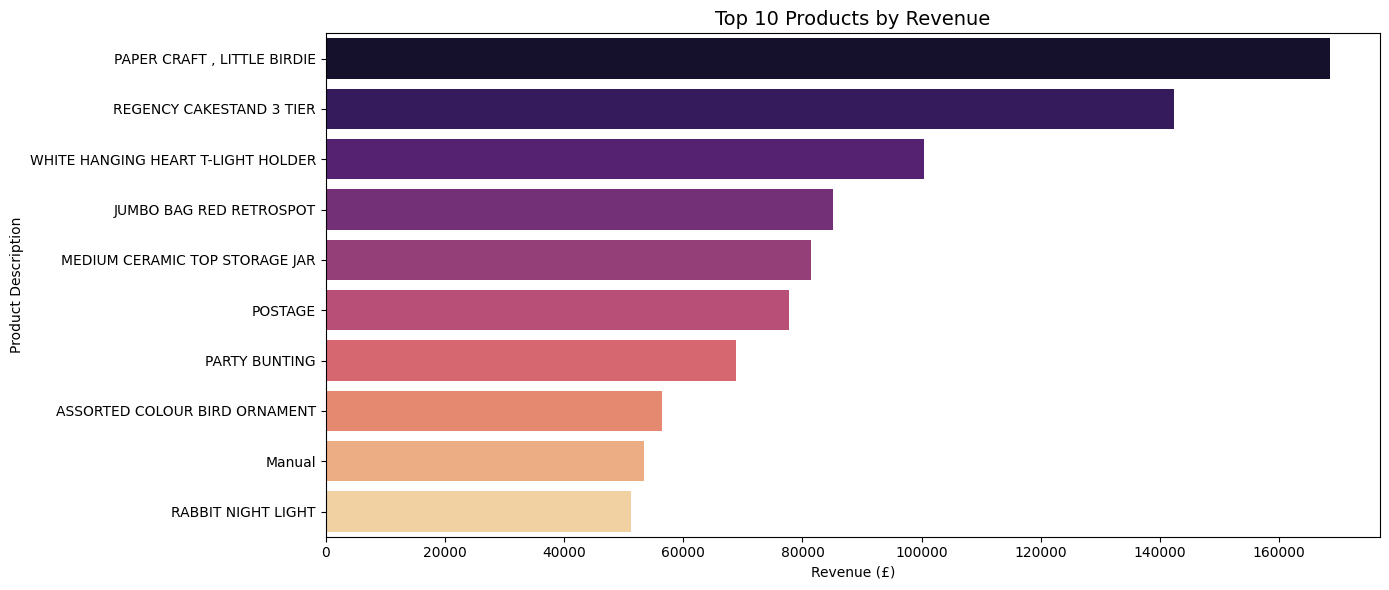

In [29]:
#Plotting top 10 products by Revenue
top10_products = product_revenue.head(10)

plt.figure(figsize=(14,6))
sns.barplot(
    data=top10_products,
    x='TotalAmount',
    y='Description',
    palette='magma'
)
plt.title("Top 10 Products by Revenue", fontsize=14)
plt.xlabel("Revenue (£)")
plt.ylabel("Product Description")
plt.tight_layout()
plt.show()

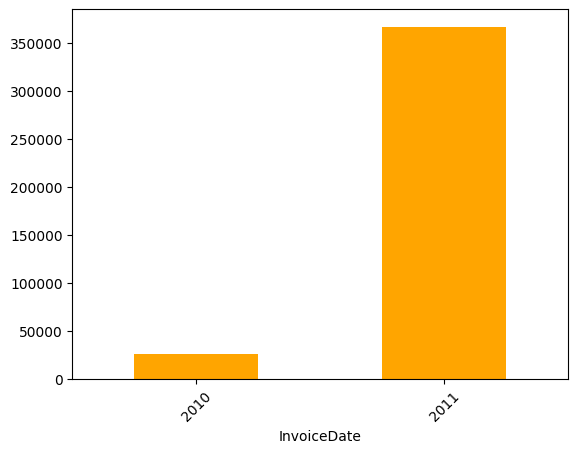

In [30]:
#visual presentation of sales in 2010 and 2011
data_clean.InvoiceDate.dt.year.value_counts(sort=False).plot(kind='bar', rot=45, color='orange');

# **5. PREP FOR BASELINE MODEL**

To prepare the Clean Online Retail transaction dataset for machine learning, we first aggregate transactions at the customer level. Then construct RFM (Recency, Frequency, Monetary) features, which capture customer purchasing  behavior and are widely used for segmentation and as baseline features in predictive models, including churn prediction using Logistic Regression.

In [32]:
#Aggregating customer Level RFM features.
snapshot_date = data_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

customer_df = data_clean.groupby('CustomerID').agg({
    'InvoiceNo': 'nunique',
    'Quantity': 'sum',
    'TotalAmount': 'sum',
    'InvoiceDate': 'max',
    'Country': 'first'
}).reset_index()

customer_df.columns = ['CustomerID','Frequency','TotalQuantity','Monetary','LastPurchase','Country']
customer_df

,CustomerID,Frequency,TotalQuantity,Monetary,LastPurchase,Country
0,12346.0,1,74215,77183.60,2011-01-18 10:01:00,United Kingdom
1,12347.0,7,2458,4310.00,2011-12-07 15:52:00,Iceland
2,12348.0,4,2341,1797.24,2011-09-25 13:13:00,Finland
3,12349.0,1,631,1757.55,2011-11-21 09:51:00,Italy
4,12350.0,1,197,334.40,2011-02-02 16:01:00,Norway
...,...,...,...,...,...,...
4333,18280.0,1,45,180.60,2011-03-07 09:52:00,United Kingdom
4334,18281.0,1,54,80.82,2011-06-12 10:53:00,United Kingdom
4335,18282.0,2,103,178.05,2011-12-02 11:43:00,United Kingdom
4336,18283.0,16,1357,2045.53,2011-12-06 12:02:00,United Kingdom


In [33]:
#Calculating Customer Recency
snapshot_date = data_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
customer_df['Recency'] = (snapshot_date - customer_df['LastPurchase']).dt.days
customer_df['Churn'] = (customer_df['Recency'] > 90).astype(int)
customer_df.head()

,CustomerID,Frequency,TotalQuantity,Monetary,LastPurchase,Country,Recency,Churn
0,12346.0,1,74215,77183.60,2011-01-18 10:01:00,United Kingdom,326,1
1,12347.0,7,2458,4310.00,2011-12-07 15:52:00,Iceland,2,0
2,12348.0,4,2341,1797.24,2011-09-25 13:13:00,Finland,75,0
3,12349.0,1,631,1757.55,2011-11-21 09:51:00,Italy,19,0
4,12350.0,1,197,334.40,2011-02-02 16:01:00,Norway,310,1


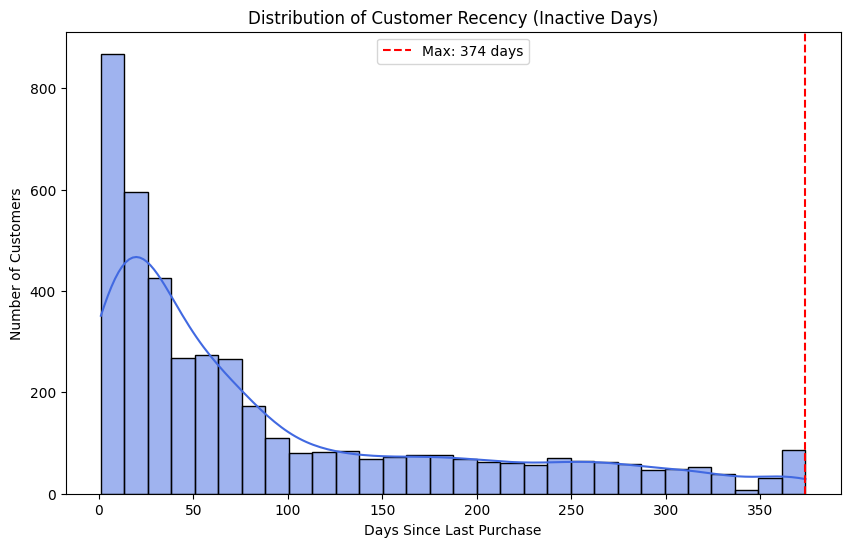

In [34]:
#Plotting Customer inactivity
plt.figure(figsize=(10, 6))
sns.histplot(customer_df['Recency'], bins=30, kde=True, color='royalblue')

# Adding a line for the maximum inactive date
plt.axvline(customer_df['Recency'].max(), color='red', linestyle='--', label=f'Max: {customer_df["Recency"].max()} days')

plt.title('Distribution of Customer Recency (Inactive Days)')
plt.xlabel('Days Since Last Purchase')
plt.ylabel('Number of Customers')
plt.legend()
plt.show()


In [35]:
import plotly.figure_factory as ff

#Calculate the correlation matrix
corr = customer_df[['Recency', 'Frequency', 'Monetary']].corr()

#Create the Heatmap
fig = ff.create_annotated_heatmap(
    z=corr.values,
    x=list(corr.columns),
    y=list(corr.index),
    annotation_text=corr.round(2).values,
    colorscale='Viridis'
)

fig.update_layout(title_text='RFM Correlation Heatmap')
fig.show()


# **Insights:**

**Frequency vs. Monetary:**
It has a high positive correlation. (More visits = more
money spent).

**Recency vs. Monetary:**
It has a negative correlation. (A higher recency number means they haven't been back in a long time).

# **6. MODELING - LOGISTIC REGRESSION**

In [36]:
#Load the Data
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [37]:
#Combine numerical and categorical data for modeling
num_features = ['Frequency', 'Monetary', 'TotalQuantity']
cat_features = ['Country']
X = customer_df[num_features + cat_features]
y = customer_df['Churn']

In [38]:
#Split train and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

Train data shape: (3470, 4)
Test data shape: (868, 4)


In [39]:
print(X_train, y_train)

      Frequency  Monetary  TotalQuantity         Country
1585          4    673.26            308  United Kingdom
454           3    607.53            499  United Kingdom
3173          1    183.70             94  United Kingdom
521           3   1247.50            134  United Kingdom
14            1    189.90             91         Belgium
...         ...       ...            ...             ...
732          26  10845.55           4724  United Kingdom
1317         15   4690.31           3850  United Kingdom
2719          2   1511.95           1793  United Kingdom
129           1    176.50             55          France
3448          6   3185.64           1595  United Kingdom

[3470 rows x 4 columns] 1585    0
454     0
3173    0
521     0
14      1
       ..
732     0
1317    0
2719    0
129     1
3448    1
Name: Churn, Length: 3470, dtype: int64


In [40]:
# COLUMN TRANSFORMER (The Transformer)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ])
print(preprocessor)

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['Frequency', 'Monetary', 'TotalQuantity']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['Country'])])


In [41]:
# THE PIPELINE
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('lgr', LogisticRegression(random_state=42, solver='liblinear'))
])

print(pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Frequency', 'Monetary',
                                                   'TotalQuantity']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Country'])])),
                ('lgr',
                 LogisticRegression(random_state=42, solver='liblinear'))])


In [42]:
# GRIDSEARCH CV (L1, L2, and C-Tuning)
param_grid = {
    'lgr__penalty': ['l1', 'l2'],
    'lgr__C': [0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print(f"Best Setup: {grid_search.best_params_}")
print(classification_report(y_test, y_pred))

Best Setup: {'lgr__C': 1, 'lgr__penalty': 'l1'}
              precision    recall  f1-score   support

           0       0.79      0.82      0.81       578
           1       0.62      0.57      0.59       290

    accuracy                           0.74       868
   macro avg       0.70      0.70      0.70       868
weighted avg       0.73      0.74      0.73       868



In [43]:
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
importance = best_model.named_steps['lgr'].coef_.flatten()
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Weight': importance
})

print(importance_df.sort_values(by='Weight', ascending=False))

                              Feature    Weight
21                 cat__Country_Japan  1.371153
7                 cat__Country_Canada  1.208896
37           cat__Country_Unspecified  0.824598
26                cat__Country_Poland  0.546573
8        cat__Country_Channel Islands  0.314028
1                       num__Monetary  0.000000
29          cat__Country_Saudi Arabia  0.000000
30             cat__Country_Singapore  0.000000
4                cat__Country_Austria  0.000000
5                cat__Country_Bahrain  0.000000
3              cat__Country_Australia  0.000000
12                  cat__Country_EIRE  0.000000
10        cat__Country_Czech Republic  0.000000
6                cat__Country_Belgium  0.000000
19                cat__Country_Israel  0.000000
15                cat__Country_France  0.000000
18               cat__Country_Iceland  0.000000
17                cat__Country_Greece  0.000000
22               cat__Country_Lebanon  0.000000
24           cat__Country_Netherlands  0

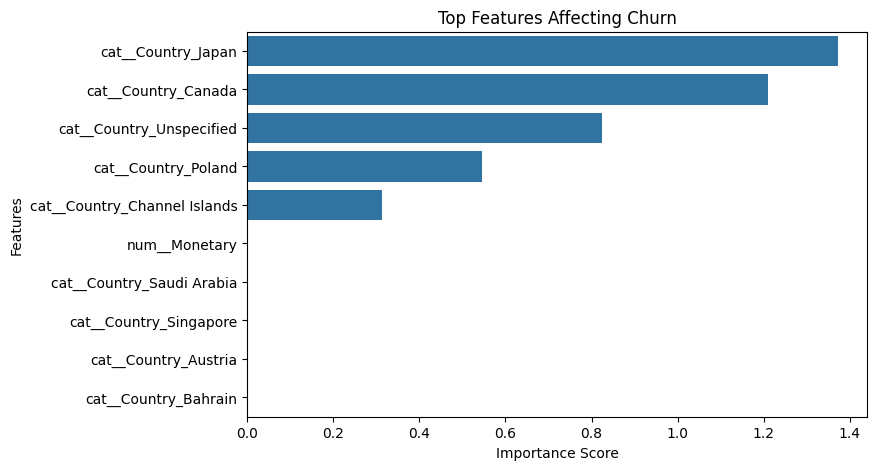

In [44]:
#Plotting Feature based on weights
imp_features = importance_df.sort_values(by='Weight', ascending=False).head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    data=imp_features,
    x='Weight',
    y='Feature'
)

plt.title("Top Features Affecting Churn")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()


In [45]:
# Calculate Churn percentages
churn_counts = customer_df['Churn'].value_counts(normalize=True) * 100

print(f"Likely to Churn (1): {churn_counts[1]:.2f}%")
print(f"Not Churning (0): {churn_counts[0]:.2f}%")


Likely to Churn (1): 33.40%
Not Churning (0): 66.60%


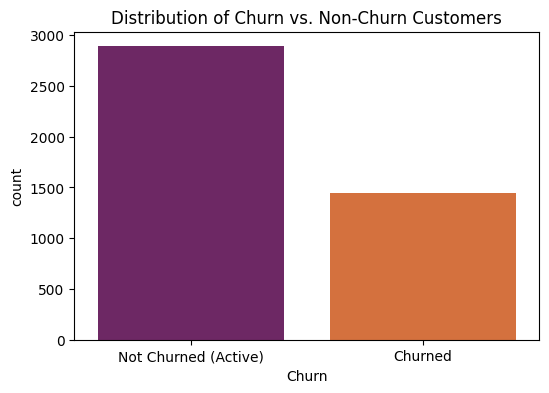

In [46]:
#Visual presentation of churn and active customers
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=customer_df, palette='inferno')
plt.title('Distribution of Churn vs. Non-Churn Customers')
plt.xticks([0, 1], ['Not Churned (Active)', 'Churned'])
plt.show()


# **OBSERVATION:**

Since the business is primarily UK-based, customers from countries outside the UK appear less engaged and show relatively higher churn tendencies compared to domestic customers.

Customers from countries such as Japan, Canada, Poland, and Iceland showed comparatively higher churn behavior in the analysis. This may be influenced by factors such as shipping time, delivery cost, or lower purchase frequency.
Geographic and customer-related features appeared to contribute significantly to churn prediction performance, indicating that customer location and purchasing behavior may influence retention.

Customers who purchase in larger quantities generally showed lower churn behavior, suggesting stronger engagement or higher dependency on the products.
Customers with higher purchase frequency were less likely to churn, indicating that repeat engagement may play an important role in long-term customer retention.



# **FURTHER INVESTIGATION**

To proceed further, how to Segment customers based on their behavior and retain them using business stratergies.